# Geschwindigkeitstrapez

Jonas Frei, 25.09.2026, jonas.frei@ost.ch

In [19]:
import numpy as np
import matplotlib.pyplot as plt

## Variablendefinition

Startposition

In [20]:
q1_0 = 0.5
q2_0 = 0.2

Endposition

In [21]:
q1_1 = 1
q2_1 = 0.3

Maximale Geschwindigkeit

In [22]:
qd1_max = 0.5
qd2_max = 0.5

Beschleunigungen

In [23]:
qdd1_acc = 0.8
qdd1_dec = -1.2
qdd2_acc = 0.8
qdd2_dec = -1.2

Startzeit

In [24]:
t0 = 0

Zeitschritt für die Berechnung der Bahn

In [25]:
dt = 0.001

## Berechnung der Zeitpunkte

In [26]:
def calc_path_times(q0, q1, qd_max, qdd_acc, qdd_dec, t0):
    if qd_max > np.sqrt(2*(qdd_acc*qdd_dec)/(qdd_dec - qdd_acc)*abs(q1 - q0)):
        qd_max = np.sqrt(2*(qdd_acc*qdd_dec)/(qdd_dec - qdd_acc)*abs(q1 - q0))
        t1 = qd_max/qdd_acc + t0
        t2 = t1
        t3 = -qd_max/qdd_dec + t2
    else:
        t1 = qd_max/qdd_acc + t0
        t2 = abs(q1 - q0)/qd_max - qd_max/(2*qdd_acc) + qd_max/(2*qdd_dec) + t1
        t3 = -qd_max/qdd_dec + t2
    return t1, t2, t3, qd_max

### Achse 1

In [27]:
t1_1, t1_2, t1_3, qd1_max = calc_path_times(q1_0, q1_1, qd1_max, qdd1_acc, qdd1_dec, t0)

### Achse 2

In [28]:
t2_1, t2_2, t2_3, qd2_max = calc_path_times(q2_0, q2_1, qd2_max, qdd2_acc, qdd2_dec, t0)

## Zeitdiskrete Berechnung der Bahnen

In [29]:
def trange(a, b, step):
    """Hilfsfunktion für die Erzeugung von Zeitvektoren.
    
    Gibt ein Array mit Werten von a bis b in Schritten von step zurück.
    Der Endpunkt b ist inklusive.
    """
    n = int(round((b - a)/step))
    return a + step*np.arange(n + 1)


def calc_path(t0, t1, t2, t3, q0, q1, qdd_acc, qdd_dec, dt):
    t = trange(0, t3, dt)
    q = np.zeros(len(t))
    q[0] = q0
    qd = np.zeros(len(t))

    if q1 < q0:
        qdd_acc = -qdd_acc
        qdd_dec = -qdd_dec

    for i in range(len(t) - 1):
        if t[i] - t0 < -1e-6:
            qd[i + 1] = qd[i]
            q[i + 1] = q[i]
        elif t[i] - t1 < -1e-6:
            qd[i + 1] = qd[i] + qdd_acc*dt
            q[i + 1] = q[i] + qd[i]*dt
        elif t[i] - t2 < -1e-6:
            qd[i + 1] = qd[i]
            q[i + 1] = q[i] + qd[i]*dt
        else:
            qd[i + 1] = qd[i] + qdd_dec*dt
            q[i + 1] = q[i] + qd[i]*dt

    return q, qd, t

### Achse 1

In [30]:
q1, qd1, t1 = calc_path(t0, t1_1, t1_2, t1_3, q1_0, q1_1, qdd1_acc, qdd1_dec, dt)

### Achse 2

In [31]:
q2, qd2, t2 = calc_path(t0, t2_1, t2_2, t2_3, q2_0, q2_1, qdd2_acc, qdd2_dec, dt)

## Plotten

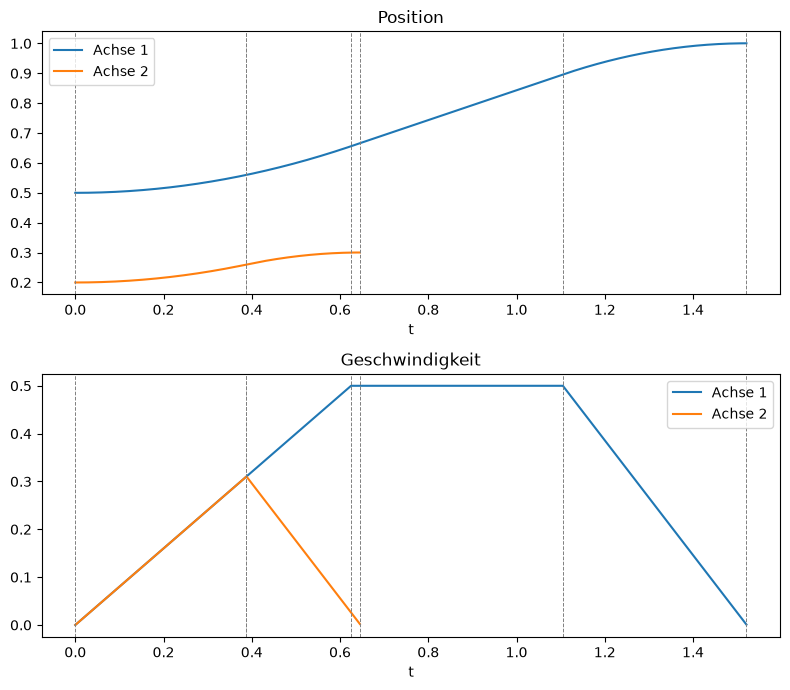

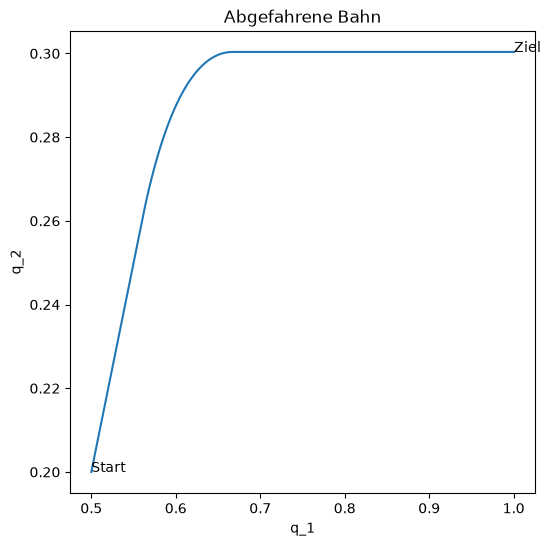

In [32]:
def plot_trajectories():
    fig, axs = plt.subplots(2, 1, figsize=(8, 7))

    axs[0].plot(t1, q1, label="Achse 1")
    axs[0].plot(t2, q2, label="Achse 2")
    axs[0].set_title("Position")
    axs[0].set_xlabel("t")
    axs[0].legend()
    for tk, label in [(t0, "t_0"), (t1_1, "t_{1,1}"), (t1_2, "t_{1,2}"), (t1_3, "t_{1,3}"),
                    (t2_1, "t_{2,1}"), (t2_2, "t_{2,2}"), (t2_3, "t_{2,3}")]:
        axs[0].axvline(tk, linestyle='--', color='gray', linewidth=0.7)

    axs[1].plot(t1, qd1, label="Achse 1")
    axs[1].plot(t2, qd2, label="Achse 2")
    axs[1].set_title("Geschwindigkeit")
    axs[1].set_xlabel("t")
    axs[1].legend()
    for tk in [t0, t1_1, t1_2, t1_3, t2_1, t2_2, t2_3]:
        axs[1].axvline(tk, linestyle='--', color='gray', linewidth=0.7)

    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 6))
    n = min(len(q1), len(q2))
    if len(q1) < len(q2):
        q1_ = np.full(len(q2), q1[-1])
        q1_[:len(q1)] = q1
        ax2.plot(q1_, q2)
        ax2.text(q1_[0], q2[0], "Start")
        ax2.text(q1_[-1], q2[-1], "Ziel")
    elif len(q2) < len(q1):
        q2_ = np.full(len(q1), q2[-1])
        q2_[:len(q2)] = q2
        ax2.plot(q1, q2_)
        ax2.text(q1[0], q2_[0], "Start")
        ax2.text(q1[-1], q2_[-1], "Ziel")
    else:
        ax2.plot(q1, q2)
        ax2.text(q1[0], q2[0], "Start")
        ax2.text(q1[-1], q2[-1], "Ziel")
    ax2.set_title("Abgefahrene Bahn")
    ax2.set_xlabel("q_1")
    ax2.set_ylabel("q_2")
    plt.show()

plot_trajectories()

## Synchronisation

In [33]:
if t2_3 > t1_3:
    qd1_max = (2*abs(q1_1 - q1_0))/(t2_3 + t2_2 - t2_1 - t0)
    qdd1_acc = qd1_max/(t2_1 - t0)
    qdd1_dec = -qd1_max/(t2_3 - t2_2)
    t1_1, t1_2, t1_3, qd1_max = calc_path_times(q1_0, q1_1, qd1_max, qdd1_acc, qdd1_dec, t0)
elif t1_3 > t2_3:
    qd2_max = (2*abs(q2_1 - q2_0))/(t1_3 + t1_2 - t1_1 - t0)
    qdd2_acc = qd2_max/(t1_1 - t0)
    qdd2_dec = -qd2_max/(t1_3 - t1_2)
    t2_1, t2_2, t2_3, qd2_max = calc_path_times(q2_0, q2_1, qd2_max, qdd2_acc, qdd2_dec, t0)

## Zeitdiskrete Berechnung der Bahnen

### Achse 1

In [34]:
q1, qd1, t1 = calc_path(t0, t1_1, t1_2, t1_3, q1_0, q1_1, qdd1_acc, qdd1_dec, dt)

### Achse 2

In [35]:
q2, qd2, t2 = calc_path(t0, t2_1, t2_2, t2_3, q2_0, q2_1, qdd2_acc, qdd2_dec, dt)

## Plotten

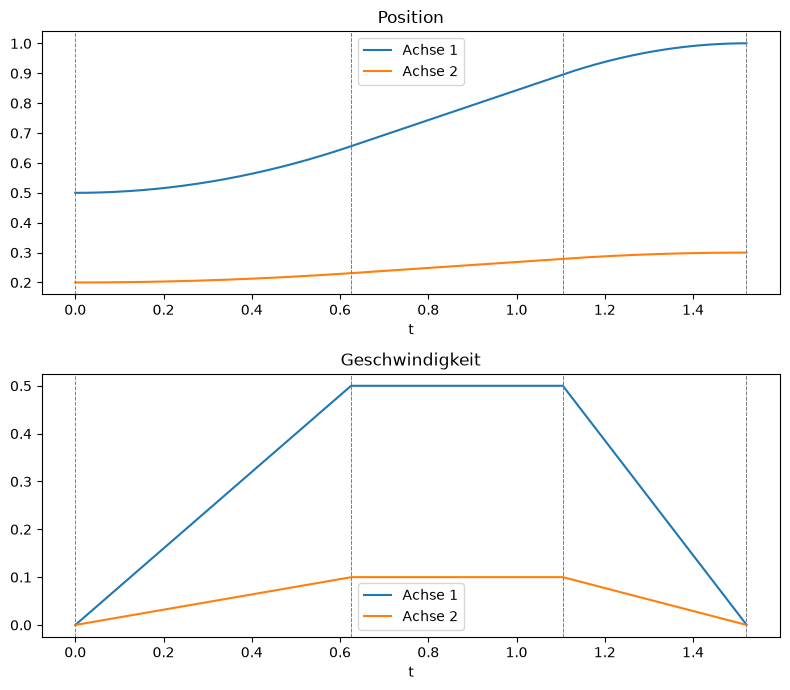

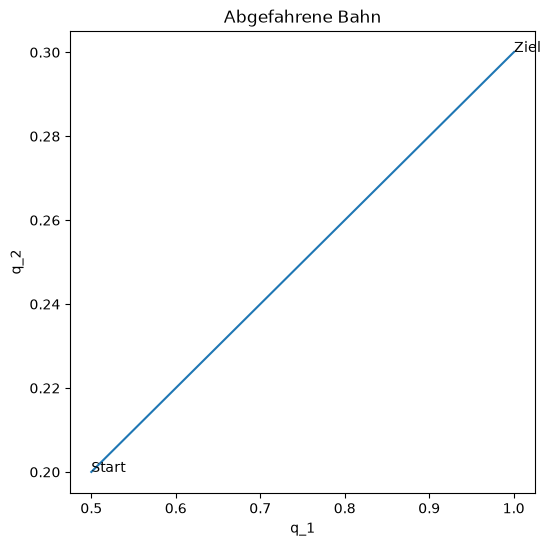

In [36]:
plot_trajectories()